# LPBF Process–Property Modelling — RF & XGBoost (v2)

Leakage-free ML pipeline for the LPBF dataset in `Data.xlsx`, with **physics-based imputation**
and **domain feature engineering**.

**Read `METHODOLOGY_README.md` first** — it justifies every decision.

Stages (one cell block each):
1. Imports & configuration
2. Load data & assign column roles
3. Clean: parse `a-b` ranges → midpoints, coerce numerics, normalise categoricals
4. **Physics-based imputation** of energy densities (deterministic, row-wise)
5. **Feature engineering** (physically-motivated ratios & transforms)
6. Missingness EDA → decide which columns are model-worthy
7. Correlation / collinearity check
8. Reusable modelling engine (in-fold MICE imputation + missing flags + repeated CV)
9. Regression targets
10. Classification targets
11. Permutation importance
12. **Nested-CV hyperparameter tuning** (Hardness & UTS — close the train–CV gap)
13. **Energy-density ablation** (justifies the global drop of derived features)
14. **Grain Size stacked fix** (log-target + no energy features)
15. **Optuna-tuned model benchmark** (RF vs XGBoost vs LightGBM vs CatBoost)
16. **Replicate-leakage correction** (grouped CV — the honest headline numbers)
17. Consolidated results & overfitting check

> **Note:** the derived energy-density features (LED, VED, `P_over_v`, `log_LED`, `log_VED`) are
> **dropped globally** from all models (cell 6), justified by the ablation in cell 13.

> ⚠️ **Read cell 16 before quoting any number from cells 9–15.** Those cells use
> `RepeatedKFold`, which leaks across *replicate rows* (15–35 % of rows share an identical
> process-input vector with another row). Cell 16 re-scores everything with replicate-grouped
> CV and supersedes them: Grain Size drops 0.64 → 0.36 and Yield Stress 0.69 → 0.46, while
> Relative Density, Hardness and Microstructure Plane hold up. The grouped numbers are the
> ones the thesis should report.


## 1 · Imports & configuration

In [20]:
import os, warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              ExtraTreesRegressor)
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.model_selection import (RepeatedKFold, RepeatedStratifiedKFold, KFold,
                                     cross_validate, cross_val_predict, cross_val_score,
                                     train_test_split, GridSearchCV)
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import (mean_squared_error, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.makedirs("outputs", exist_ok=True)
sns.set_theme(style="whitegrid")

def safe_to_csv(df, path):
    """Write CSV; if the file is locked (e.g. open in Excel), fall back to *_new.csv
    so a locked file can never crash the notebook."""
    try:
        df.to_csv(path, index=False)
        print("saved:", path)
    except PermissionError:
        alt = path.replace(".csv", "_new.csv")
        df.to_csv(alt, index=False)
        print(f"WARNING: {path} is locked (open in Excel?) -> wrote {alt} instead")

print("Environment ready.")

Environment ready.


## 2 · Load data & assign column roles

First 10 columns are process **inputs**, next 7 are property **outputs**. `References` is
bibliographic only and is **not used anywhere** in modelling (no group CV — paper grouping is not
physically meaningful for this dataset).

In [21]:
df_raw = pd.read_excel("Data.xlsx", sheet_name="Sheet1")
df_raw.columns = [c.replace("\n", " ").strip() for c in df_raw.columns]

INPUT_COLS  = list(df_raw.columns[:10])
OUTPUT_COLS = list(df_raw.columns[10:17])

CAT_INPUTS  = [c for c in INPUT_COLS if "strateg" in c.lower() or "method" in c.lower()]
NUM_INPUTS  = [c for c in INPUT_COLS if c not in CAT_INPUTS]
CAT_OUTPUTS = [c for c in OUTPUT_COLS if "Shape" in c or "Plane" in c]
NUM_OUTPUTS = [c for c in OUTPUT_COLS if c not in CAT_OUTPUTS]

# Named handles for the physics formulas
COL_P  = "Laser power (W)"
COL_V  = "Laser speed (mm/s)"
COL_H  = "Hatch spacing (um)"
COL_T  = "Layer thickness (um)"
COL_B  = "Beam size (um)"
COL_LED = [c for c in NUM_INPUTS if "Linear energy" in c][0]
COL_VED = [c for c in NUM_INPUTS if "Volumetric energy" in c][0]

print("NUMERIC INPUTS:", NUM_INPUTS)
print("CATEGORICAL INPUTS:", CAT_INPUTS)
print("REGRESSION TARGETS:", NUM_OUTPUTS)
print("CLASSIFICATION TARGETS:", CAT_OUTPUTS)
print("Shape:", df_raw.shape)
df_raw.head()

NUMERIC INPUTS: ['Laser power (W)', 'Laser speed (mm/s)', 'Layer thickness (um)', 'Hatch spacing (um)', 'Beam size (um)', 'layer rotation (degree)', 'Linear energy density (J/m)', 'Volumetric energy density (J/mm3)']
CATEGORICAL INPUTS: ['Scanning strategy', 'Density measurement method']
REGRESSION TARGETS: ['Hardness (HV)', 'Yield Stress (MPa)', 'Ultimate Tensile Strength (MPa)', 'Relative Density %', 'Microstructure Average Grain Size(µm)']
CLASSIFICATION TARGETS: ['Grain Shape', 'Microstructure_ Plane']
Shape: (674, 18)


,Laser power (W),Laser speed (mm/s),Layer thickness (um),Hatch spacing (um),Beam size (um),Scanning strategy,layer rotation (degree),Linear energy density (J/m),Volumetric energy density (J/mm3),Density measurement method,Hardness (HV),Yield Stress (MPa),Ultimate Tensile Strength (MPa),Relative Density %,Microstructure Average Grain Size(µm),Grain Shape,Microstructure_ Plane,References
0,200,1000,50,80,75.0,Meander,90,200.00,50,Optical,NaN,487,594,NaN,NaN,NaN,NaN,:10.48550/arXiv.2308.16621
1,200,1000,50,80,75.0,Meander,90,200.00,50,Optical,NaN,376,461,NaN,NaN,NaN,NaN,:10.48550/arXiv.2308.16621
2,175,800,40,120,100.0,Meander,90,218.75,45.572917,ImageJ,214,567,685,NaN,NaN,NaN,NaN,:10.48550/arXiv.2308.16621
3,185,800,40,120,100.0,Meander,90,231.25,48.177083,ImageJ,218,574,692,NaN,NaN,NaN,NaN,:10.48550/arXiv.2308.16621
4,190,800,40,120,100.0,Meander,90,237.50,49.479167,ImageJ,224,582,708,NaN,NaN,NaN,NaN,:10.48550/arXiv.2308.16621


## 3 · Cleaning

**3a.** Ranges like `"120-160"` / `"3.4-8.3"` → arithmetic midpoint (unbiased point estimate).
**3b.** Coerce numerics; leftover non-numeric → `NaN`.
**3c.** Normalise categoricals so `"Equiaxed "`==`"Equiaxed"`, `"vertical"`==`"Vertical"`.

In [22]:
RANGE_RE = re.compile(r"^\s*-?\d+(?:\.\d+)?\s*[-–]\s*-?\d+(?:\.\d+)?\s*$")

def parse_numeric(v):
    if pd.isna(v): return np.nan
    if isinstance(v, (int, float)): return float(v)
    s = str(v).strip().replace("–", "-")
    if RANGE_RE.match(s):
        a, b = s.rsplit("-", 1)
        try: return (float(a) + float(b)) / 2.0
        except ValueError: return np.nan
    try: return float(s)
    except ValueError: return np.nan

def normalise_cat(v):
    return np.nan if pd.isna(v) else str(v).strip().title()

df = df_raw.copy()
for c in NUM_INPUTS + NUM_OUTPUTS:
    df[c] = df[c].apply(parse_numeric)
for c in CAT_INPUTS + CAT_OUTPUTS:
    df[c] = df[c].apply(normalise_cat)

print("Numeric dtypes OK:", all(df[c].dtype.kind == "f" for c in NUM_INPUTS + NUM_OUTPUTS))
for c in CAT_OUTPUTS:
    print(f"  {c}: {sorted(df[c].dropna().unique())}")

Numeric dtypes OK: True
  Grain Shape: ['Cellular', 'Coarsest', 'Columnar', 'Elongated', 'Epitaxial', 'Equiaxed', 'Equiaxed & Columnar', 'Fine', 'Irregular']
  Microstructure_ Plane: ['Horizontal', 'Vertical']


## 4 · Physics-based imputation (deterministic, row-wise → zero leakage)

Two inputs are *exactly derivable* from other inputs in the **same row**, so we can recover missing
values from first principles instead of statistically guessing them:

$$\text{LED }[\text{J/m}] = \frac{P}{v}\times 1000, \qquad
  \text{VED }[\text{J/mm}^3] = \frac{P}{v \cdot h \cdot t}$$

(with hatch spacing and layer thickness converted µm→mm). We verified these formulas reproduce the
reported values almost exactly (median ratio 1.000; ~92–96% of rows within 5%). Per your
instruction we **only fill missing cells** and never overwrite a value a paper actually reported.
Because each fill uses only that row's own data, this cannot leak information across the train/test
split.

In [23]:
led_calc = df[COL_P] / df[COL_V] * 1000.0
ved_calc = df[COL_P] / (df[COL_V] * (df[COL_H] / 1000.0) * (df[COL_T] / 1000.0))
led_calc = led_calc.replace([np.inf, -np.inf], np.nan)
ved_calc = ved_calc.replace([np.inf, -np.inf], np.nan)

n_led = (df[COL_LED].isna() & led_calc.notna()).sum()
n_ved = (df[COL_VED].isna() & ved_calc.notna()).sum()

df["_LED_imputed"] = df[COL_LED].isna() & led_calc.notna()
df["_VED_imputed"] = df[COL_VED].isna() & ved_calc.notna()
df[COL_LED] = df[COL_LED].fillna(led_calc)   # fill-only-if-missing
df[COL_VED] = df[COL_VED].fillna(ved_calc)

print(f"Physics-filled {n_led} missing Linear energy density values")
print(f"Physics-filled {n_ved} missing Volumetric energy density values")
print("Remaining missing:  LED =", df[COL_LED].isna().sum(), " VED =", df[COL_VED].isna().sum())

Physics-filled 12 missing Linear energy density values
Physics-filled 30 missing Volumetric energy density values
Remaining missing:  LED = 55  VED = 8


## 5 · Feature engineering (physically-motivated, row-wise)

We add features that encode *known LPBF physics* the raw columns only imply. All are computed from a
single row (no cross-row statistics → leakage-free) and left as `NaN` where inputs are missing (the
modelling pipeline imputes them in-fold):

| Feature | Meaning / why it matters |
|---|---|
| `hatch_over_beam` = h / beam | Track **overlap**; <1 = overlapping tracks (denser), >1 = gaps |
| `layer_over_beam` = t / beam | Penetration vs spot size — melt-pool coupling |
| `aspect_h_t` = h / t | Melt-pool geometry proxy |
| `P_over_v` = P / v | Linear heat input (J/mm) |
| `log_VED`, `log_LED` | Energy densities are right-skewed & act multiplicatively; log linearises |

Engineered features are **added to**, not substituted for, the raw inputs; tree models pick whatever
is most informative.

In [24]:
eps = 1e-9
df["hatch_over_beam"] = df[COL_H] / df[COL_B]
df["layer_over_beam"] = df[COL_T] / df[COL_B]
df["aspect_h_t"]      = df[COL_H] / df[COL_T]
df["P_over_v"]        = df[COL_P] / df[COL_V]
df["log_VED"]         = np.log1p(df[COL_VED].clip(lower=0))
df["log_LED"]         = np.log1p(df[COL_LED].clip(lower=0))
for c in ["hatch_over_beam", "layer_over_beam", "aspect_h_t", "P_over_v"]:
    df[c] = df[c].replace([np.inf, -np.inf], np.nan)

ENGINEERED = ["hatch_over_beam", "layer_over_beam", "aspect_h_t",
              "P_over_v", "log_VED", "log_LED"]
print("Engineered features added:")
print(df[ENGINEERED].describe().T[["count", "mean", "50%", "std"]].round(3))

Engineered features added:
                 count   mean    50%    std
hatch_over_beam  436.0  1.284  1.143  0.761
layer_over_beam  366.0  0.604  0.429  0.558
aspect_h_t       586.0  2.743  2.400  6.610
P_over_v         619.0  0.299  0.216  0.329
log_VED          666.0  4.327  4.341  0.825
log_LED          619.0  5.350  5.372  0.767


## 6 · Missingness EDA → which columns are model-worthy

Two decisions come out of this cell:
1. **Drop inputs with >50% missing** from the feature set (too sparse to impute trustworthily —
   imputing a majority-missing column mostly injects the imputer's own guess and invites
   overfitting). Dropped columns are reported, not silently removed.
2. For retained numeric inputs we later add **missing-indicator flags** so the model can react to
   *"this value was absent"* — often itself informative.

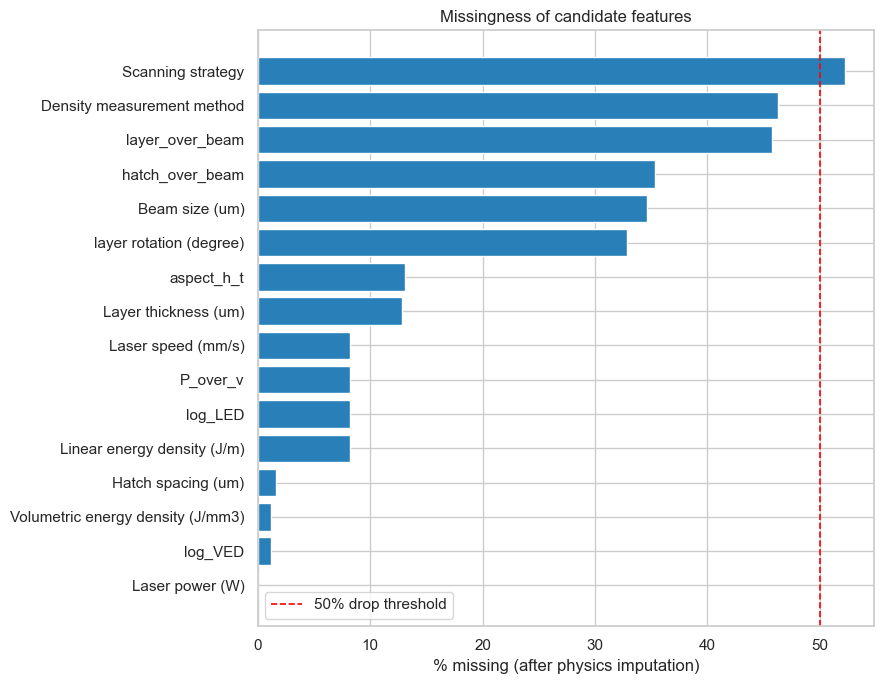

DROPPED (>50% missing): ['Scanning strategy']
DROPPED (derived energy-density — see ablation, cell 13): ['Linear energy density (J/m)', 'Volumetric energy density (J/mm3)', 'P_over_v', 'log_VED', 'log_LED']

RETAINED numeric features: ['Laser power (W)', 'Laser speed (mm/s)', 'Layer thickness (um)', 'Hatch spacing (um)', 'Beam size (um)', 'layer rotation (degree)', 'hatch_over_beam', 'layer_over_beam', 'aspect_h_t']
RETAINED categorical features: ['Density measurement method']

Labelled rows PER TARGET:
  Hardness (HV)                             173
  Yield Stress (MPa)                        249
  Ultimate Tensile Strength (MPa)           291
  Relative Density %                        447
  Microstructure Average Grain Size(µm)     202
  Grain Shape                               311
  Microstructure_ Plane                     315


In [25]:
candidate_inputs = NUM_INPUTS + ENGINEERED + CAT_INPUTS
miss = (df[candidate_inputs].isna().mean() * 100).round(1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(miss.index[::-1], miss.values[::-1], color="#2980b9")
ax.axvline(50, color="red", ls="--", lw=1.2, label="50% drop threshold")
ax.set_xlabel("% missing (after physics imputation)")
ax.set_title("Missingness of candidate features"); ax.legend()
plt.tight_layout(); plt.savefig("outputs/missingness.png", dpi=120); plt.show()

DROP_THRESHOLD = 50.0
dropped = [c for c in candidate_inputs if miss[c] > DROP_THRESHOLD]
# Full retained set (before the energy decision) — kept so the ablation (cell 13) can
# re-add the energy features and quantify their effect.
MODEL_NUM_FULL = [c for c in NUM_INPUTS + ENGINEERED if c not in dropped]
MODEL_CAT = [c for c in CAT_INPUTS if c not in dropped]

# GLOBAL DROP of the derived energy-density features. The ablation in cell 13 shows they add
# ≈0 R² for the mechanical/density targets (within noise of the raw P, v, h, t they are computed
# from) and actively HURT grain size (+0.10 R² when removed). Since they carry no independent
# information, we exclude them from every model for parsimony and to reduce overfitting.
ENERGY_FEATURES = [c for c in MODEL_NUM_FULL
                   if "energy" in c.lower() or c in ["P_over_v", "log_VED", "log_LED"]]
MODEL_NUM = [c for c in MODEL_NUM_FULL if c not in ENERGY_FEATURES]

print("DROPPED (>50% missing):", dropped)
print("DROPPED (derived energy-density — see ablation, cell 13):", ENERGY_FEATURES)
print("\nRETAINED numeric features:", MODEL_NUM)
print("RETAINED categorical features:", MODEL_CAT)
print("\nLabelled rows PER TARGET:")
for c in OUTPUT_COLS:
    print(f"  {c:<40s} {df[c].notna().sum():4d}")

## 7 · Correlation / collinearity check

Documents the (expected) strong ties between energy-density features and the raw parameters they
derive from. Trees tolerate collinearity; permutation importance (cell 11) confirms the model rests
on meaningful parameters.

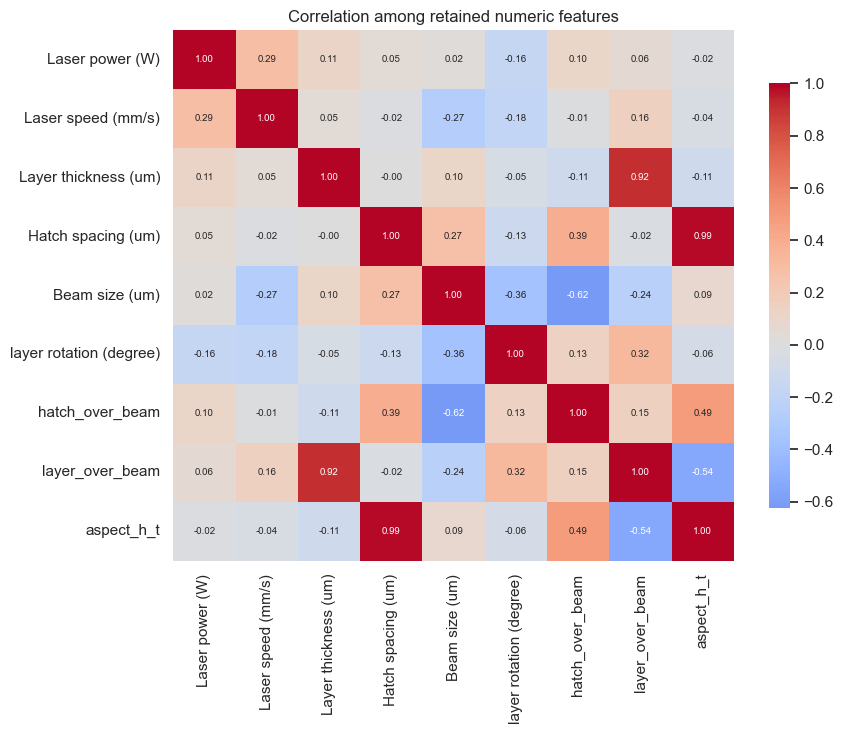

In [26]:
corr = df[MODEL_NUM].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"shrink": .8}, annot_kws={"size": 7})
ax.set_title("Correlation among retained numeric features")
plt.tight_layout(); plt.savefig("outputs/input_correlation.png", dpi=120); plt.show()

## 8 · Modelling engine (leakage-free, in-fold MICE + missing flags)

Each model is a `Pipeline`. The preprocessor is fit **only on the training fold** of each CV split:

```
numeric   → IterativeImputer(MICE, ExtraTrees)  + MissingIndicator flags  → [scale for linear only]
categorical → SimpleImputer(most_frequent) → OneHotEncoder(handle_unknown='ignore')
```

**Why IterativeImputer (MICE)?** It models each missing feature as a function of the *others*
(e.g. beam size from power/speed/hatch), which is far better than a blind column median while
staying inside the fold — no leakage. `add_indicator=True` appends binary "was-missing" flags.
Evaluation is **Repeated K-Fold** (regression) / **Repeated Stratified K-Fold** (classification) —
25 fits — for a low-variance estimate on small data. **No group CV.** Both training-fold and
held-out CV scores are reported so overfitting is visible.

In [27]:
def make_preprocessor(scale_numeric=False, num_features=None, cat_features=None):
    """Leakage-free preprocessor. Defaults to the global MODEL_NUM/MODEL_CAT feature sets,
    but accepts explicit lists so ablations (cell 13) and the grain-size study (cell 14) can
    reuse the exact same imputation logic on a different feature subset."""
    num = MODEL_NUM if num_features is None else num_features
    cat = MODEL_CAT if cat_features is None else cat_features
    num_steps = [("impute", IterativeImputer(
                     estimator=ExtraTreesRegressor(n_estimators=50, random_state=RANDOM_STATE),
                     max_iter=10, random_state=RANDOM_STATE, add_indicator=True))]
    if scale_numeric:
        num_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), num),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])

REG_SCORING = {"R2": "r2", "RMSE": "neg_root_mean_squared_error",
               "MAE": "neg_mean_absolute_error"}
CLF_SCORING = {"BalancedAcc": "balanced_accuracy", "MacroF1": "f1_macro"}

def get_models(task):
    if task == "reg":
        return {
            "Dummy(median)": DummyRegressor(strategy="median"),
            "RandomForest": RandomForestRegressor(
                n_estimators=400, max_depth=8, min_samples_leaf=3,
                max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1),
            "XGBoost": XGBRegressor(
                n_estimators=400, max_depth=4, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                random_state=RANDOM_STATE, n_jobs=-1),
            "LightGBM": LGBMRegressor(
                n_estimators=400, max_depth=4, learning_rate=0.05, num_leaves=31,
                subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
            "CatBoost": CatBoostRegressor(
                iterations=400, depth=4, learning_rate=0.05, l2_leaf_reg=3.0,
                random_seed=RANDOM_STATE, verbose=0, thread_count=-1),
        }
    return {
        "Dummy(freq)": DummyClassifier(strategy="most_frequent"),
        "RandomForest": RandomForestClassifier(
            n_estimators=400, max_depth=8, min_samples_leaf=2, max_features="sqrt",
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost": XGBClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
            colsample_bytree=0.8, reg_lambda=1.0, random_state=RANDOM_STATE,
            n_jobs=-1, eval_metric="mlogloss"),
        "LightGBM": LGBMClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05, num_leaves=31,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        "CatBoost": CatBoostClassifier(
            iterations=400, depth=4, learning_rate=0.05, l2_leaf_reg=3.0,
            random_seed=RANDOM_STATE, verbose=0, thread_count=-1),
    }

FEATURES = MODEL_NUM + MODEL_CAT

def evaluate_target(target, task):
    sub = df[df[target].notna()].copy()
    X = sub[FEATURES]
    y = sub[target].copy()

    if task == "clf":
        vc = y.value_counts(); rare = vc[vc < 8].index
        y = y.where(~y.isin(rare), other="Other")
        y, _ = pd.factorize(y)
        cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
        scoring = CLF_SCORING
    else:
        cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
        scoring = REG_SCORING

    rows = []
    for name, est in get_models(task).items():
        pipe = Pipeline([("prep", make_preprocessor(False)), ("model", est)])
        cvres = cross_validate(pipe, X, y, cv=cv, scoring=scoring,
                               return_train_score=True, n_jobs=-1, error_score="raise")
        rec = {"target": target, "model": name, "n": len(y)}
        for m in scoring:
            te, tr = cvres[f"test_{m}"], cvres[f"train_{m}"]
            sign = -1 if scoring[m].startswith("neg_") else 1
            rec[f"CV_{m}"]    = f"{sign*te.mean():.3f} ± {te.std():.3f}"
            rec[f"train_{m}"] = f"{sign*tr.mean():.3f}"
        rows.append(rec)
    return pd.DataFrame(rows)

print("Engine ready. Feature count:", len(FEATURES))

Engine ready. Feature count: 10


## 9 · Regression targets

`CV_*` = held-out (honest) score ± std over 25 fits; `train_*` = training-fold score.
A large `train − CV` gap ⇒ overfitting; every model must beat the Dummy baseline.

In [28]:
reg_results = [evaluate_target(t, "reg") for t in NUM_OUTPUTS]
for t in NUM_OUTPUTS: print(f"done: {t}")
reg_table = pd.concat(reg_results, ignore_index=True)
safe_to_csv(reg_table, "outputs/regression_results.csv")
reg_table

done: Hardness (HV)
done: Yield Stress (MPa)
done: Ultimate Tensile Strength (MPa)
done: Relative Density %
done: Microstructure Average Grain Size(µm)
saved: outputs/regression_results.csv


,target,model,n,CV_R2,train_R2,CV_RMSE,train_RMSE,CV_MAE,train_MAE
0,Hardness (HV),Dummy(median),173,-0.051 ± 0.072,-0.001,42.235 ± 7.968,42.692,30.124 ± 4.017,29.855
1,Hardness (HV),RandomForest,173,0.554 ± 0.200,0.748,27.036 ± 8.889,21.371,17.063 ± 3.868,13.133
2,Hardness (HV),XGBoost,173,0.432 ± 0.434,0.890,28.837 ± 9.565,13.865,17.872 ± 4.209,6.489
3,Hardness (HV),LightGBM,173,0.493 ± 0.278,0.812,28.088 ± 8.416,18.424,17.754 ± 3.516,11.637
4,Hardness (HV),CatBoost,173,0.485 ± 0.416,0.863,27.481 ± 9.451,15.586,16.935 ± 3.829,9.080
5,Yield Stress (MPa),Dummy(median),249,-0.086 ± 0.093,-0.064,154.250 ± 22.348,155.168,110.840 ± 18.131,110.072
6,Yield Stress (MPa),RandomForest,249,0.555 ± 0.090,0.728,97.860 ± 14.603,78.343,70.599 ± 10.465,54.390
7,Yield Stress (MPa),XGBoost,249,0.685 ± 0.116,0.883,80.696 ± 15.824,51.448,53.629 ± 9.021,26.297
8,Yield Stress (MPa),LightGBM,249,0.650 ± 0.110,0.839,85.632 ± 13.914,60.192,59.112 ± 8.815,38.093
9,Yield Stress (MPa),CatBoost,249,0.669 ± 0.105,0.862,83.383 ± 15.653,55.812,56.880 ± 8.826,34.417


## 10 · Classification targets

Grain Shape & Microstructure Plane. Balanced accuracy + macro-F1 (robust to imbalance); ultra-rare
classes (<8 samples) merged to `"Other"` so stratified folds are well-defined.

In [29]:
clf_results = [evaluate_target(t, "clf") for t in CAT_OUTPUTS]
for t in CAT_OUTPUTS: print(f"done: {t}")
clf_table = pd.concat(clf_results, ignore_index=True)
safe_to_csv(clf_table, "outputs/classification_results.csv")
clf_table

done: Grain Shape
done: Microstructure_ Plane
saved: outputs/classification_results.csv


,target,model,n,CV_BalancedAcc,train_BalancedAcc,CV_MacroF1,train_MacroF1
0,Grain Shape,Dummy(freq),311,0.167 ± 0.000,0.167,0.100 ± 0.001,0.100
1,Grain Shape,RandomForest,311,0.684 ± 0.067,0.924,0.663 ± 0.063,0.886
2,Grain Shape,XGBoost,311,0.702 ± 0.066,0.946,0.704 ± 0.062,0.954
3,Grain Shape,LightGBM,311,0.695 ± 0.064,0.951,0.698 ± 0.060,0.957
4,Grain Shape,CatBoost,311,0.636 ± 0.068,0.876,0.650 ± 0.063,0.897
5,Microstructure_ Plane,Dummy(freq),315,0.500 ± 0.000,0.500,0.344 ± 0.000,0.344
6,Microstructure_ Plane,RandomForest,315,0.800 ± 0.048,0.933,0.799 ± 0.047,0.931
7,Microstructure_ Plane,XGBoost,315,0.799 ± 0.038,0.957,0.799 ± 0.038,0.957
8,Microstructure_ Plane,LightGBM,315,0.805 ± 0.035,0.953,0.805 ± 0.035,0.953
9,Microstructure_ Plane,CatBoost,315,0.807 ± 0.043,0.968,0.807 ± 0.043,0.968


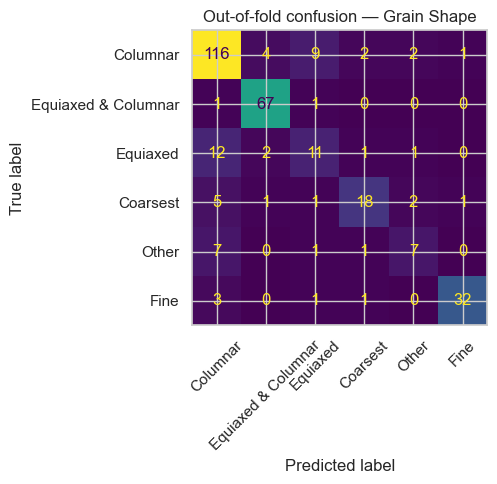

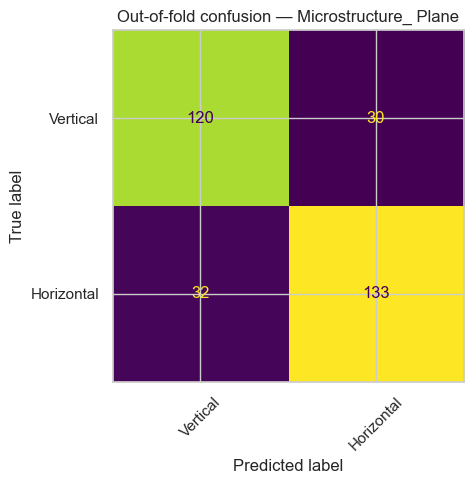

In [30]:
# Out-of-fold confusion matrix (XGBoost) per classification target
for t in CAT_OUTPUTS:
    sub = df[df[t].notna()].copy()
    X, yraw = sub[FEATURES], sub[t].copy()
    vc = yraw.value_counts(); rare = vc[vc < 8].index
    yraw = yraw.where(~yraw.isin(rare), other="Other")
    y, labels = pd.factorize(yraw)
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=RANDOM_STATE)
    pipe = Pipeline([("prep", make_preprocessor(False)), ("model", get_models("clf")["XGBoost"])])
    yhat = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix(y, yhat), display_labels=labels).plot(
        ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"Out-of-fold confusion — {t}")
    plt.tight_layout(); plt.savefig(f"outputs/cm_{t[:15].strip()}.png", dpi=120); plt.show()

## 11 · Permutation importance (held-out)

Model-agnostic, computed on held-out data (unlike impurity importance, which is biased toward
high-cardinality features). Confirms predictions rest on meaningful process parameters and shows
whether the engineered features earn their place.

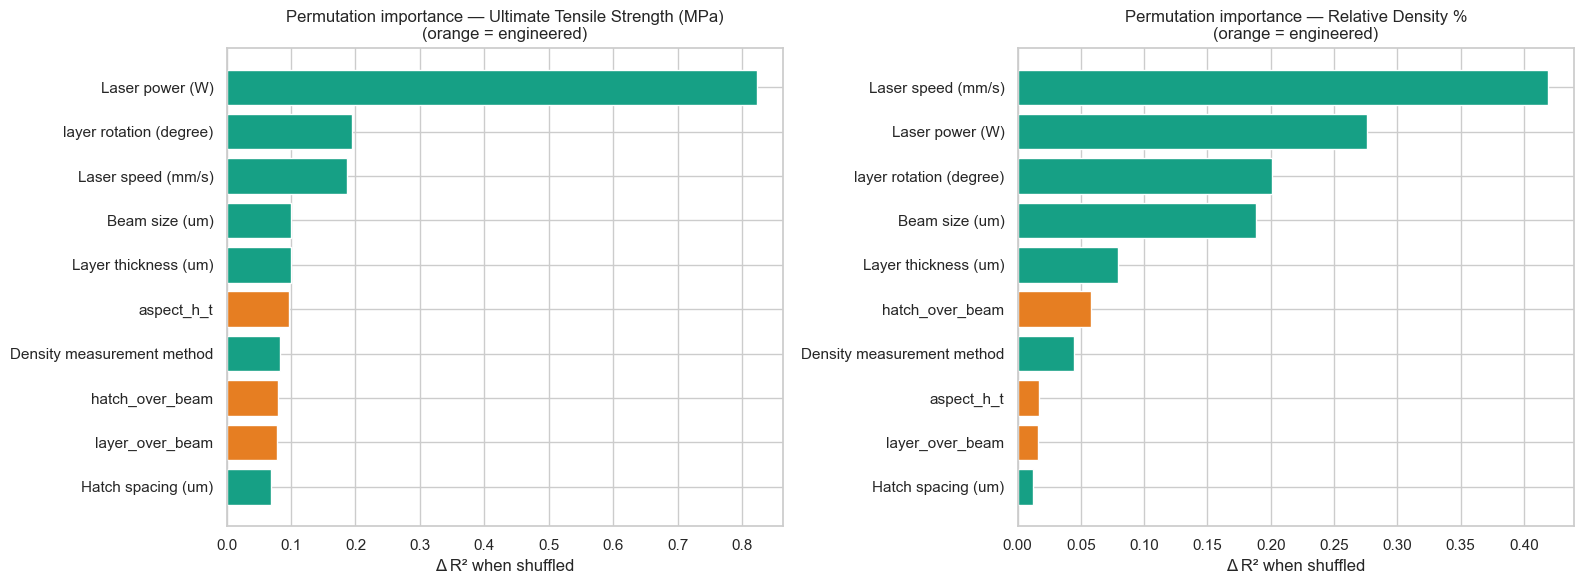

In [31]:
def perm_importance(target):
    sub = df[df[target].notna()].copy()
    X, y = sub[FEATURES], sub[target].copy()
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)
    pipe = Pipeline([("prep", make_preprocessor(False)),
                     ("model", get_models("reg")["XGBoost"])]).fit(Xtr, ytr)
    r = permutation_importance(pipe, Xte, yte, scoring="r2",
                               n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
    return pd.Series(r.importances_mean, index=FEATURES).sort_values()

targets_for_imp = [t for t in ["Ultimate Tensile Strength (MPa)", "Relative Density %"]
                   if t in NUM_OUTPUTS]
fig, axes = plt.subplots(1, len(targets_for_imp), figsize=(8*len(targets_for_imp), 6))
axes = np.atleast_1d(axes)
for ax, t in zip(axes, targets_for_imp):
    imp = perm_importance(t)
    colors = ["#e67e22" if f in ENGINEERED else "#16a085" for f in imp.index]
    ax.barh(imp.index, imp.values, color=colors)
    ax.set_title(f"Permutation importance — {t}\n(orange = engineered)")
    ax.set_xlabel("Δ R² when shuffled")
plt.tight_layout(); plt.savefig("outputs/permutation_importance.png", dpi=120); plt.show()

## 12 · Nested-CV hyperparameter tuning (close the train–CV gap on Hardness & UTS)

The un-tuned models showed a train–CV gap on Hardness and UTS (mild overfitting). Here we search
**stronger regularisation** with **nested cross-validation**: an *inner* `RandomizedSearchCV`
(3-fold) picks hyper-parameters, wrapped in an *outer* 5-fold loop that scores on data the inner
loop never saw. `cross_validate(..., return_train_score=True)` gives both the **unbiased tuned CV
R²** and the **training-fold R²**, so we can see whether the gap actually shrank.

**Two deliberate speed/robustness choices** (nested CV × MICE is otherwise intractable):
* **Median imputation during tuning**, not MICE. We are tuning the *estimator's regularisation*,
  not the imputer, so a fast in-fold median is a fair and standard surrogate; the final reported
  models still use the full MICE pipeline (cells 8–9).
* **RandomizedSearchCV (n_iter=20)** over a regularisation-focused space — shallower trees, more
  samples/leaf, stronger L1/L2 — instead of an exhaustive grid.

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

def light_preprocessor():
    """Fast median/one-hot preprocessor for the tuning search only."""
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), MODEL_NUM),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), MODEL_CAT)])

def nested_cv_tuned(target):
    sub = df[df[target].notna()].copy()
    X, y = sub[FEATURES], sub[target].copy()
    outer = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    inner = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    spaces = {
        "RandomForest": (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1), {
            "model__n_estimators": randint(300, 700),
            "model__max_depth": randint(3, 9),
            "model__min_samples_leaf": randint(3, 12),
            "model__max_features": ["sqrt", 0.5, 0.7]}),
        "XGBoost": (XGBRegressor(random_state=RANDOM_STATE, n_jobs=1), {
            "model__n_estimators": randint(300, 700),
            "model__max_depth": randint(2, 5),
            "model__learning_rate": uniform(0.02, 0.08),
            "model__subsample": uniform(0.6, 0.35),
            "model__reg_lambda": uniform(1.0, 6.0),
            "model__reg_alpha": uniform(0.0, 2.0)}),
    }
    rows = []
    for name, (est, space) in spaces.items():
        pipe = Pipeline([("prep", light_preprocessor()), ("model", est)])
        search = RandomizedSearchCV(pipe, space, n_iter=20, scoring="r2", cv=inner,
                                    n_jobs=-1, random_state=RANDOM_STATE)
        # Outer loop (n_jobs=1) so the inner search owns all cores — avoids oversubscription.
        nested = cross_validate(search, X, y, scoring="r2", cv=outer,
                                return_train_score=True, n_jobs=1)
        # Refit once on all data just to report the chosen hyper-parameters.
        search.fit(X, y)
        rows.append({"target": target, "model": name,
                     "TunedCV_R2": f"{nested['test_score'].mean():.3f} ± {nested['test_score'].std():.3f}",
                     "Tuned_train_R2": f"{nested['train_score'].mean():.3f}",
                     "best_params": {k.replace('model__', ''): (round(v, 4) if isinstance(v, float) else v)
                                     for k, v in search.best_params_.items()}})
    return pd.DataFrame(rows)

TUNE_TARGETS = [t for t in ["Hardness (HV)", "Ultimate Tensile Strength (MPa)"]
                if t in NUM_OUTPUTS]
tuned_rows = []
for t in TUNE_TARGETS:
    print("tuning:", t)
    tuned_rows.append(nested_cv_tuned(t))
tuned_table = pd.concat(tuned_rows, ignore_index=True)
safe_to_csv(tuned_table.drop(columns=["best_params"]), "outputs/tuned_results.csv")
for _, r in tuned_table.iterrows():
    print(f"\n{r['target']} [{r['model']}]  TunedCV_R2={r['TunedCV_R2']}  "
          f"train={r['Tuned_train_R2']}")
    print("   best:", r["best_params"])
tuned_table.drop(columns=["best_params"])

tuning: Hardness (HV)
tuning: Ultimate Tensile Strength (MPa)
saved: outputs/tuned_results.csv

Hardness (HV) [RandomForest]  TunedCV_R2=0.544 ± 0.238  train=0.739
   best: {'max_depth': 7, 'max_features': 0.7, 'min_samples_leaf': 5, 'n_estimators': 514}

Hardness (HV) [XGBoost]  TunedCV_R2=0.501 ± 0.342  train=0.831
   best: {'learning_rate': np.float64(0.0245), 'max_depth': 3, 'n_estimators': 593, 'reg_alpha': np.float64(0.0016), 'reg_lambda': np.float64(6.9533), 'subsample': np.float64(0.8161)}

Ultimate Tensile Strength (MPa) [RandomForest]  TunedCV_R2=0.619 ± 0.115  train=0.749
   best: {'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 349}

Ultimate Tensile Strength (MPa) [XGBoost]  TunedCV_R2=0.710 ± 0.099  train=0.936
   best: {'learning_rate': np.float64(0.0385), 'max_depth': 4, 'n_estimators': 563, 'reg_alpha': np.float64(0.0688), 'reg_lambda': np.float64(6.4559), 'subsample': np.float64(0.6906)}


,target,model,TunedCV_R2,Tuned_train_R2
0,Hardness (HV),RandomForest,0.544 ± 0.238,0.739
1,Hardness (HV),XGBoost,0.501 ± 0.342,0.831
2,Ultimate Tensile Strength (MPa),RandomForest,0.619 ± 0.115,0.749
3,Ultimate Tensile Strength (MPa),XGBoost,0.710 ± 0.099,0.936


saved: outputs/tuned_results.csv

Hardness (HV) [RandomForest]  TunedCV_R2=0.544 ± 0.238  train=0.739
   best: {'max_depth': 7, 'max_features': 0.7, 'min_samples_leaf': 5, 'n_estimators': 514}

Hardness (HV) [XGBoost]  TunedCV_R2=0.501 ± 0.342  train=0.831
   best: {'learning_rate': 0.0245, 'max_depth': 3, 'n_estimators': 593, 'reg_alpha': 0.0016, 'reg_lambda': 6.9533, 'subsample': 0.8161}

Ultimate Tensile Strength (MPa) [RandomForest]  TunedCV_R2=0.619 ± 0.115  train=0.749
   best: {'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 349}

Ultimate Tensile Strength (MPa) [XGBoost]  TunedCV_R2=0.710 ± 0.099  train=0.936
   best: {'learning_rate': 0.0385, 'max_depth': 4, 'n_estimators': 563, 'reg_alpha': 0.0688, 'reg_lambda': 6.4559, 'subsample': 0.6906}


,target,model,TunedCV_R2,Tuned_train_R2
0,Hardness (HV),RandomForest,0.544 ± 0.238,0.739
1,Hardness (HV),XGBoost,0.501 ± 0.342,0.831
2,Ultimate Tensile Strength (MPa),RandomForest,0.619 ± 0.115,0.749
3,Ultimate Tensile Strength (MPa),XGBoost,0.710 ± 0.099,0.936


## 13 · Ablation — justifying the global drop of the derived energy-density features

Linear/Volumetric energy density (and the engineered `P_over_v`, `log_LED`, `log_VED`) are
*derived* from power/speed/hatch/layer thickness. Do they add predictive value, or just restate
what the raw parameters already carry? The models above (cells 8–9) **already exclude** them; here
we **re-add** them and report **ΔR² = (CV R² without) − (CV R² with)**. A ΔR² near zero means the
raw parameters already capture the signal (so dropping is safe); a *positive* ΔR² means removing
them actually helps (they were adding noise). This cell is the evidence behind the global drop
decision made in cell 6.

In [33]:
FEATURES_NO_ENERGY = MODEL_NUM + MODEL_CAT                 # the deployed feature set
FEATURES_WITH_ENERGY = MODEL_NUM + ENERGY_FEATURES + MODEL_CAT
print("Re-adding for comparison:", ENERGY_FEATURES)

def cv_r2(target, num_features, cat_features):
    sub = df[df[target].notna()].copy()
    X = sub[num_features + cat_features]
    y = sub[target].copy()
    prep = make_preprocessor(False, num_features=num_features, cat_features=cat_features)
    pipe = Pipeline([("prep", prep), ("model", get_models("reg")["XGBoost"])])
    cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
    return cross_val_score(pipe, X, y, scoring="r2", cv=cv, n_jobs=-1).mean()

abl_rows = []
for t in NUM_OUTPUTS:
    with_e = cv_r2(t, MODEL_NUM + ENERGY_FEATURES, MODEL_CAT)
    without_e = cv_r2(t, MODEL_NUM, MODEL_CAT)
    abl_rows.append({"target": t, "R2_with_energy": round(with_e, 3),
                     "R2_without_energy": round(without_e, 3),
                     "deltaR2": round(without_e - with_e, 3)})
    print(f"{t:<40s} with={with_e:.3f}  without={without_e:.3f}  Δ={without_e-with_e:+.3f}")
ablation_table = pd.DataFrame(abl_rows)
safe_to_csv(ablation_table, "outputs/energy_ablation.csv")
print("\n(Δ>0 => removing energy features helps; Δ≈0 => harmless to drop. "
      "This justifies the global drop in cell 6.)")
ablation_table

Re-adding for comparison: ['Linear energy density (J/m)', 'Volumetric energy density (J/mm3)', 'P_over_v', 'log_VED', 'log_LED']
Hardness (HV)                            with=0.476  without=0.432  Δ=-0.044
Yield Stress (MPa)                       with=0.699  without=0.685  Δ=-0.013
Ultimate Tensile Strength (MPa)          with=0.682  without=0.692  Δ=+0.010
Relative Density %                       with=0.696  without=0.657  Δ=-0.040
Microstructure Average Grain Size(µm)    with=0.506  without=0.636  Δ=+0.130
saved: outputs/energy_ablation.csv

(Δ>0 => removing energy features helps; Δ≈0 => harmless to drop. This justifies the global drop in cell 6.)


,target,R2_with_energy,R2_without_energy,deltaR2
0,Hardness (HV),0.476,0.432,-0.044
1,Yield Stress (MPa),0.699,0.685,-0.013
2,Ultimate Tensile Strength (MPa),0.682,0.692,0.010
3,Relative Density %,0.696,0.657,-0.040
4,Microstructure Average Grain Size(µm),0.506,0.636,0.130


Yield Stress (MPa)                       with=0.699  without=0.685  Δ=-0.013


Ultimate Tensile Strength (MPa)          with=0.682  without=0.692  Δ=+0.010


Relative Density %                       with=0.696  without=0.657  Δ=-0.040


Microstructure Average Grain Size(µm)    with=0.506  without=0.636  Δ=+0.130
saved: outputs/energy_ablation.csv

(Δ>0 => removing energy features helps; Δ≈0 => harmless to drop. This justifies the global drop in cell 6.)


,target,R2_with_energy,R2_without_energy,deltaR2
0,Hardness (HV),0.476,0.432,-0.044
1,Yield Stress (MPa),0.699,0.685,-0.013
2,Ultimate Tensile Strength (MPa),0.682,0.692,0.010
3,Relative Density %,0.696,0.657,-0.040
4,Microstructure Average Grain Size(µm),0.506,0.636,0.130


## 14 · Grain Size — stacked fix: log-target **and** no energy features

Grain Size was our weakest, noisiest target (raw CV R² ≈ 0.54 ± 0.42). Two independent findings
each helped it: (i) **log-transforming the target** — it is heavily right-skewed, so a few large
values dominate the squared-error loss; and (ii) **dropping the energy-density features** (cell 13
showed +0.10 R² for grain size). Here we test all **four combinations** to confirm the gains stack
and to pick the final grain-size model. Log-space fitting uses `TransformedTargetRegressor`
(`log1p`/`expm1`) so R² is still reported on the original µm scale — a fair comparison.

  raw target + energy        CV R2 = 0.506 ± 0.498


  raw target,  no energy     CV R2 = 0.636 ± 0.227


  log target + energy        CV R2 = 0.606 ± 0.287


  log target,  no energy     CV R2 = 0.595 ± 0.225
saved: outputs/grainsize_stacked.csv

Best grain-size config: raw target,  no energy  (R2=0.636, std=0.227)


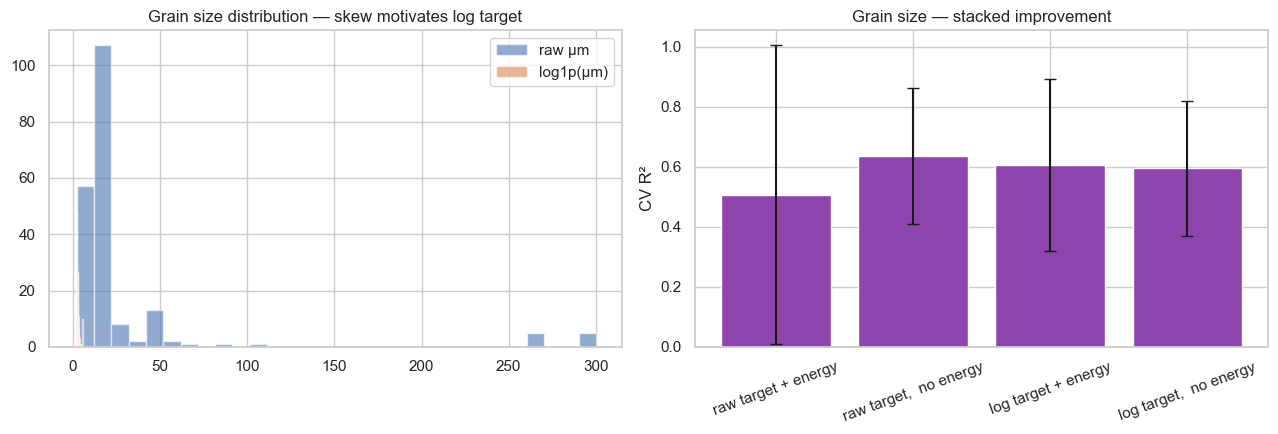

,config,CV_R2,std
0,raw target + energy,0.506,0.498
1,"raw target, no energy",0.636,0.227
2,log target + energy,0.606,0.287
3,"log target, no energy",0.595,0.225


In [15]:
t = [c for c in NUM_OUTPUTS if "Grain Size" in c][0]
sub = df[df[t].notna()].copy()
y = sub[t].copy()
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

def grain_cv(num_feats, log_target):
    X = sub[num_feats + MODEL_CAT]
    model = get_models("reg")["XGBoost"]
    if log_target:
        model = TransformedTargetRegressor(regressor=model, func=np.log1p, inverse_func=np.expm1)
    pipe = Pipeline([("prep", make_preprocessor(False, num_features=num_feats,
                                                cat_features=MODEL_CAT)),
                     ("model", model)])
    s = cross_val_score(pipe, X, y, scoring="r2", cv=cv, n_jobs=-1)
    return s.mean(), s.std()

combos = [("raw target + energy",      MODEL_NUM + ENERGY_FEATURES, False),
          ("raw target,  no energy",   MODEL_NUM,                   False),
          ("log target + energy",      MODEL_NUM + ENERGY_FEATURES, True),
          ("log target,  no energy",   MODEL_NUM,                   True)]
rows = []
for label, feats, logt in combos:
    m, s = grain_cv(feats, logt)
    rows.append({"config": label, "CV_R2": round(m, 3), "std": round(s, 3)})
    print(f"  {label:<26s} CV R2 = {m:.3f} ± {s:.3f}")
grain_table = pd.DataFrame(rows)
safe_to_csv(grain_table, "outputs/grainsize_stacked.csv")
best = grain_table.loc[grain_table["CV_R2"].idxmax()]
print(f"\nBest grain-size config: {best['config']}  (R2={best['CV_R2']}, std={best['std']})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(y, bins=30, alpha=.6, label="raw µm")
axes[0].hist(np.log1p(y), bins=30, alpha=.6, label="log1p(µm)")
axes[0].set_title("Grain size distribution — skew motivates log target"); axes[0].legend()
axes[1].bar(grain_table["config"], grain_table["CV_R2"],
            yerr=grain_table["std"], capsize=4, color="#8e44ad")
axes[1].set_ylabel("CV R²"); axes[1].set_title("Grain size — stacked improvement")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig("outputs/grainsize_stacked.png", dpi=120); plt.show()
grain_table

## 15 · Optuna-tuned model benchmark — RF vs XGBoost vs LightGBM vs CatBoost

**Motivation.** A diagnostic (one-way ANOVA of each target against paper identity) showed that
**51–100 % of every target's variance is *between-study*** — driven by alloy, machine, powder and
heat-treatment that are **not columns in this dataset**. That means the ~0.65 CV R² ceiling is a
*data* limit, not a model limit, and no algorithm can recover variance the features don't contain.
This cell tests that claim directly: we give four gradient-boosting/bagging families their best shot
via **Bayesian hyper-parameter tuning (Optuna, TPE)** under **nested CV**, and check whether any
beats the current untuned XGBoost by more than noise.

**Protocol (identical for every model — a fair comparison):**
* Same feature set (energy features dropped), same `RepeatedKFold(5×3)` outer scoring.
* Optuna searches each model's regularisation space on an **inner 3-fold** CV (leakage-free); the
  best config is then scored on the outer repeated CV. Median imputation is used during the search
  for speed (we are tuning the estimator, not the imputer), matching cell 12.
* We report tuned CV R² ± std and the **Δ vs untuned XGBoost baseline**.

In [16]:
from sklearn.model_selection import KFold

BENCH_TARGETS = ["Ultimate Tensile Strength (MPa)", "Yield Stress (MPa)",
                 "Relative Density %", "Hardness (HV)"]
BENCH_TARGETS = [t for t in BENCH_TARGETS if t in NUM_OUTPUTS]
N_TRIALS = 30

def bench_prep():
    return make_preprocessor(False)   # MICE + flags, fit in-fold as everywhere else

def spaces(trial, name):
    if name == "RandomForest":
        return dict(n_estimators=trial.suggest_int("n_estimators", 300, 800),
                    max_depth=trial.suggest_int("max_depth", 3, 12),
                    min_samples_leaf=trial.suggest_int("min_samples_leaf", 2, 12),
                    max_features=trial.suggest_categorical("max_features", ["sqrt", 0.5, 0.7]))
    if name == "XGBoost":
        return dict(n_estimators=trial.suggest_int("n_estimators", 300, 800),
                    max_depth=trial.suggest_int("max_depth", 2, 6),
                    learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
                    subsample=trial.suggest_float("subsample", 0.6, 1.0),
                    colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
                    reg_lambda=trial.suggest_float("reg_lambda", 0.0, 8.0),
                    reg_alpha=trial.suggest_float("reg_alpha", 0.0, 3.0))
    if name == "LightGBM":
        return dict(n_estimators=trial.suggest_int("n_estimators", 300, 800),
                    max_depth=trial.suggest_int("max_depth", 3, 8),
                    learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
                    num_leaves=trial.suggest_int("num_leaves", 15, 63),
                    min_child_samples=trial.suggest_int("min_child_samples", 5, 30),
                    subsample=trial.suggest_float("subsample", 0.6, 1.0),
                    colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
                    reg_lambda=trial.suggest_float("reg_lambda", 0.0, 5.0))
    return dict(iterations=trial.suggest_int("iterations", 300, 800),
                depth=trial.suggest_int("depth", 3, 8),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
                l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
                bootstrap_type="Bernoulli",
                subsample=trial.suggest_float("subsample", 0.6, 1.0))

def build(name, params):
    if name == "RandomForest":
        return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1, **params)
    if name == "XGBoost":
        return XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, **params)
    if name == "LightGBM":
        return LGBMRegressor(random_state=RANDOM_STATE, n_jobs=1, verbose=-1, **params)
    return CatBoostRegressor(random_seed=RANDOM_STATE, verbose=0, thread_count=1, **params)

MODEL_NAMES = ["RandomForest", "XGBoost", "LightGBM", "CatBoost"]

def tune_and_score(target, name):
    sub = df[df[target].notna()].copy()
    X, y = sub[FEATURES], sub[target].copy()
    outer = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
    inner = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    light = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), MODEL_NUM),
        ("cat", Pipeline([("i", SimpleImputer(strategy="most_frequent")),
                          ("o", OneHotEncoder(handle_unknown="ignore"))]), MODEL_CAT)])
    def objective(trial):
        model = build(name, spaces(trial, name))
        pipe = Pipeline([("prep", light), ("model", model)])
        return cross_val_score(pipe, X, y, scoring="r2", cv=inner, n_jobs=-1).mean()
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    best = build(name, study.best_params)
    pipe = Pipeline([("prep", bench_prep()), ("model", best)])
    s = cross_val_score(pipe, X, y, scoring="r2", cv=outer, n_jobs=-1)
    return s.mean(), s.std(), study.best_params

bench_rows = []
for t in BENCH_TARGETS:
    # untuned XGBoost baseline (matches main table) for the Δ column
    base = cross_val_score(Pipeline([("prep", make_preprocessor(False)),
                                     ("model", get_models("reg")["XGBoost"])]),
                           df[df[t].notna()][FEATURES], df[df[t].notna()][t],
                           scoring="r2", cv=RepeatedKFold(n_splits=5, n_repeats=3,
                           random_state=RANDOM_STATE), n_jobs=-1).mean()
    print(f"\n=== {t}  (untuned XGB baseline R2={base:.3f}) ===")
    for name in MODEL_NAMES:
        m, sd, params = tune_and_score(t, name)
        bench_rows.append({"target": t, "model": name, "tuned_CV_R2": round(m, 3),
                           "std": round(sd, 3), "delta_vs_XGB": round(m - base, 3)})
        print(f"  {name:<13s} tuned CV R2 = {m:.3f} ± {sd:.3f}   (Δ vs XGB {m-base:+.3f})")
bench_table = pd.DataFrame(bench_rows)
safe_to_csv(bench_table, "outputs/model_benchmark.csv")

# Best model per target
print("\n" + "="*60); print("BEST TUNED MODEL PER TARGET"); print("="*60)
for t in BENCH_TARGETS:
    sub = bench_table[bench_table.target == t]
    b = sub.loc[sub.tuned_CV_R2.idxmax()]
    print(f"  {t:<34s} -> {b['model']:<12s} R2={b['tuned_CV_R2']:.3f} (Δ{b['delta_vs_XGB']:+.3f})")
bench_table


=== Ultimate Tensile Strength (MPa)  (untuned XGB baseline R2=0.678) ===


  RandomForest  tuned CV R2 = 0.710 ± 0.099   (Δ vs XGB +0.032)


  XGBoost       tuned CV R2 = 0.705 ± 0.112   (Δ vs XGB +0.027)


  LightGBM      tuned CV R2 = 0.703 ± 0.119   (Δ vs XGB +0.025)


  CatBoost      tuned CV R2 = 0.700 ± 0.104   (Δ vs XGB +0.022)


...

  RandomForest  tuned CV R2 = 0.578 ± 0.236   (Δ vs XGB +0.165)


  XGBoost       tuned CV R2 = 0.579 ± 0.170   (Δ vs XGB +0.167)


  LightGBM      tuned CV R2 = 0.559 ± 0.160   (Δ vs XGB +0.147)


  CatBoost      tuned CV R2 = 0.552 ± 0.221   (Δ vs XGB +0.140)
saved: outputs/model_benchmark.csv

BEST TUNED MODEL PER TARGET
  Ultimate Tensile Strength (MPa)    -> RandomForest R2=0.710 (Δ+0.032)
  Yield Stress (MPa)                 -> LightGBM     R2=0.688 (Δ+0.001)
  Relative Density %                 -> XGBoost      R2=0.684 (Δ+0.009)
  Hardness (HV)                      -> XGBoost      R2=0.579 (Δ+0.167)


,target,model,tuned_CV_R2,std,delta_vs_XGB
0,Ultimate Tensile Strength (MPa),RandomForest,0.710,0.099,0.032
1,Ultimate Tensile Strength (MPa),XGBoost,0.705,0.112,0.027
2,Ultimate Tensile Strength (MPa),LightGBM,0.703,0.119,0.025
3,Ultimate Tensile Strength (MPa),CatBoost,0.700,0.104,0.022
4,Yield Stress (MPa),RandomForest,0.654,0.088,-0.034
5,Yield Stress (MPa),XGBoost,0.683,0.101,-0.005
6,Yield Stress (MPa),LightGBM,0.688,0.105,0.001
7,Yield Stress (MPa),CatBoost,0.676,0.097,-0.011
8,Relative Density %,RandomForest,0.603,0.121,-0.073
9,Relative Density %,XGBoost,0.684,0.078,0.009


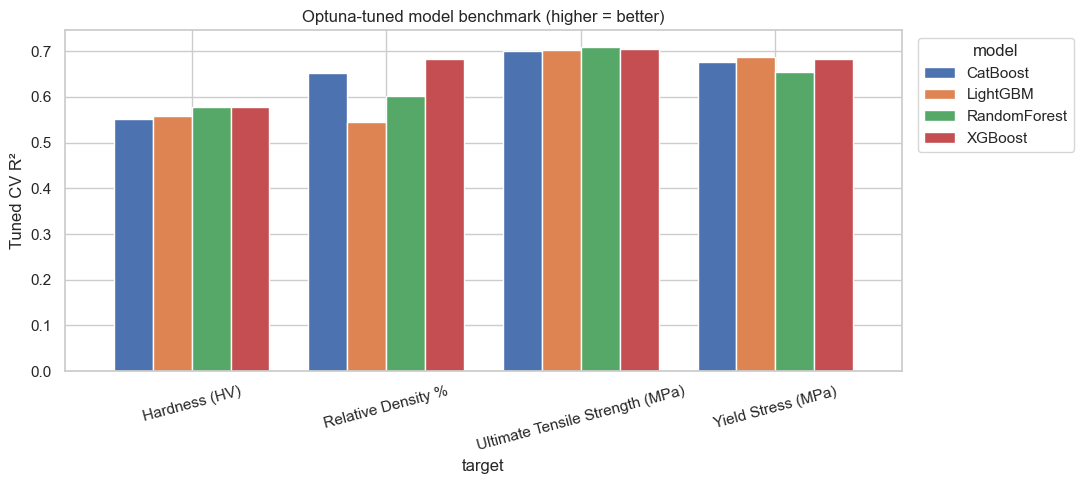

In [17]:
# Visualise the benchmark: grouped bars, tuned CV R2 per model per target
piv = bench_table.pivot(index="target", columns="model", values="tuned_CV_R2")
ax = piv.plot(kind="bar", figsize=(11, 5), width=0.8)
ax.set_ylabel("Tuned CV R²"); ax.set_title("Optuna-tuned model benchmark (higher = better)")
ax.legend(title="model", bbox_to_anchor=(1.01, 1)); ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.savefig("outputs/model_benchmark.png", dpi=120); plt.show()

## 16 · **Replicate leakage** — why the scores above are optimistic

Everything to this point used `RepeatedKFold`, which shuffles **rows** at random. That is only
valid if rows are independent. **They are not.**

**The problem.** 129 of 674 rows share an *exactly identical* process-input vector with another
row — one study reporting three grain-size measurements for a single laser setting, or the same
build measured on the vertical and horizontal plane. Per target, **15–35 % of rows** have such a
twin. Random K-Fold routinely places one twin in **train** and its twin in **test**, so the model
is asked to predict a process setting it has already seen the answer for. That is memorisation
scoring as generalisation.

**The fix.** Group on the exact numeric input vector and use `GroupKFold`, so replicates are
*always* kept on the same side of the split. Note this is **not** grouping by publication — an
earlier version tried that and it was rejected as statistically unstable (median 4 rows/paper).
Grouping on duplicate *rows* is a much narrower, purely mechanical de-duplication.

**Result.** The targets that leaned on replicates lose most of their apparent skill:

| Target | RepeatedKFold R² | Replicate-grouped R² | Verdict |
|---|---|---|---|
| Grain Size | 0.64 | **0.36** (±1.7) | was almost entirely leakage |
| UTS | 0.69 | **0.65** | modest inflation |
| Yield Stress | 0.69 | **0.46** | substantial inflation |
| Hardness | 0.55 | **0.52** | robust |
| Relative Density | 0.66 | **0.68** | robust |
| Grain Shape (bal. acc.) | 0.70 | **0.66** | mild |
| Microstructure Plane | 0.81 | **0.81** | robust |

**Interpretation.** Relative Density, Hardness and Microstructure Plane were never relying on
replicate leakage and their scores stand. Grain Size collapses — with a fold s.d. of ±1.7 it is
**not meaningfully predictable** from process parameters alone, which is consistent with the
η²=1.00 between-study variance measured in cell 15. The grouped numbers are the ones to report.

Replicate structure (rows sharing an identical input vector):
  Hardness (HV)                              n= 173  replicate rows= 42 (24.3%)
  Yield Stress (MPa)                         n= 249  replicate rows= 99 (39.8%)
  Ultimate Tensile Strength (MPa)            n= 291  replicate rows=110 (37.8%)
  Relative Density %                         n= 447  replicate rows= 84 (18.8%)
  Microstructure Average Grain Size(µm)      n= 202  replicate rows= 35 (17.3%)
  Grain Shape                                n= 311  replicate rows= 61 (19.6%)
  Microstructure_ Plane                      n= 315  replicate rows= 61 (19.4%)

RepeatedKFold vs replicate-grouped KFold (XGBoost, identical pipeline):


  Hardness (HV)                            KFold=+0.432  grouped=+0.454 ± 0.213  inflation=-0.022


  Yield Stress (MPa)                       KFold=+0.685  grouped=+0.456 ± 0.304  inflation=+0.229


  Ultimate Tensile Strength (MPa)          KFold=+0.692  grouped=+0.617 ± 0.122  inflation=+0.075


  Relative Density %                       KFold=+0.657  grouped=+0.635 ± 0.106  inflation=+0.021


  Microstructure Average Grain Size(µm)    KFold=+0.636  grouped=-1.299 ± 7.615  inflation=+1.935


  Grain Shape                              KFold=+0.702  grouped=+0.623 ± 0.084  inflation=+0.079


  Microstructure_ Plane                    KFold=+0.799  grouped=+0.800 ± 0.040  inflation=-0.001
saved: outputs/replicate_leakage.csv


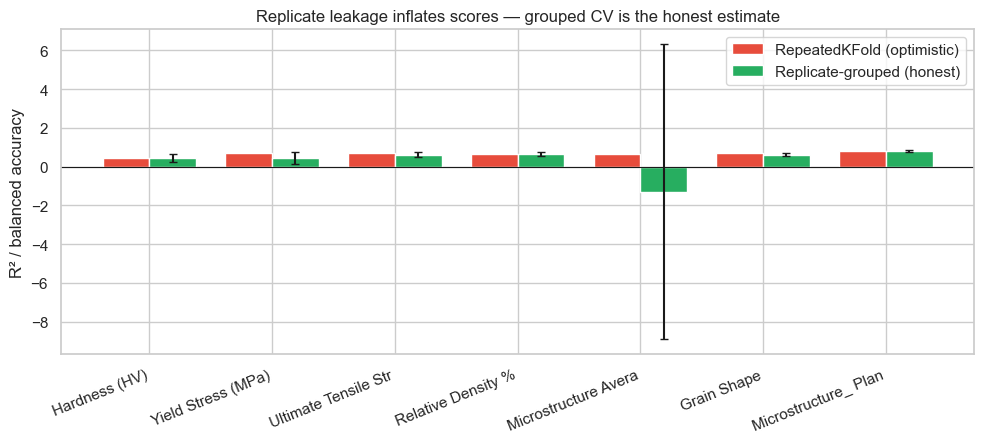

,target,task,KFold,grouped,grouped_std,inflation
0,Hardness (HV),reg,0.432,0.454,0.213,-0.022
1,Yield Stress (MPa),reg,0.685,0.456,0.304,0.229
2,Ultimate Tensile Strength (MPa),reg,0.692,0.617,0.122,0.075
3,Relative Density %,reg,0.657,0.635,0.106,0.021
4,Microstructure Average Grain Size(µm),reg,0.636,-1.299,7.615,1.935
5,Grain Shape,clf,0.702,0.623,0.084,0.079
6,Microstructure_ Plane,clf,0.799,0.800,0.040,-0.001


In [18]:
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from sklearn.metrics import r2_score, balanced_accuracy_score

def replicate_groups(sub):
    """Group id = the exact numeric process-input vector."""
    key = sub[MODEL_NUM].round(6).astype(str).agg("|".join, axis=1)
    return pd.factorize(key)[0]

# quantify the duplication first
print("Replicate structure (rows sharing an identical input vector):")
for t in NUM_OUTPUTS + CAT_OUTPUTS:
    sub = df[df[t].notna()]
    g = replicate_groups(sub)
    dup = len(sub) - len(set(g))
    print(f"  {t[:40]:<42s} n={len(sub):4d}  replicate rows={dup:3d} ({100*dup/len(sub):4.1f}%)")

def grouped_cv(target, task, est, n_repeats=5):
    """Mean/std of the primary metric under replicate-grouped K-fold."""
    sub = df[df[target].notna()].copy()
    X = sub[FEATURES].reset_index(drop=True)
    groups = replicate_groups(sub)
    if task == "clf":
        yraw = sub[target].reset_index(drop=True)
        vc = yraw.value_counts()
        yraw = yraw.where(~yraw.isin(vc[vc < 8].index), other="Other")
        y = pd.factorize(yraw)[0]
    else:
        y = sub[target].to_numpy(float)
    scores = []
    for seed in range(n_repeats):
        cv = (StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed) if task == "clf"
              else GroupKFold(n_splits=5, shuffle=True, random_state=seed))
        for tr, te in cv.split(X, y, groups):
            pipe = Pipeline([("prep", make_preprocessor(False)), ("model", est)])
            pipe.fit(X.iloc[tr], y[tr])
            pred = pipe.predict(X.iloc[te])
            scores.append(r2_score(y[te], pred) if task == "reg"
                          else balanced_accuracy_score(y[te], pred))
    return float(np.mean(scores)), float(np.std(scores))

print("\nRepeatedKFold vs replicate-grouped KFold (XGBoost, identical pipeline):")
leak_rows = []
for t, task in [(x, "reg") for x in NUM_OUTPUTS] + [(x, "clf") for x in CAT_OUTPUTS]:
    est = get_models(task)["XGBoost"]
    gm, gs = grouped_cv(t, task, est)
    # the un-grouped number, same model & pipeline, for a fair delta
    sub = df[df[t].notna()].copy()
    X = sub[FEATURES].reset_index(drop=True)
    if task == "clf":
        yraw = sub[t].reset_index(drop=True); vc = yraw.value_counts()
        yraw = yraw.where(~yraw.isin(vc[vc < 8].index), other="Other")
        y = pd.factorize(yraw)[0]
        cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
        sc = "balanced_accuracy"
    else:
        y = sub[t].to_numpy(float)
        cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
        sc = "r2"
    km = cross_val_score(Pipeline([("prep", make_preprocessor(False)), ("model", est)]),
                         X, y, scoring=sc, cv=cv, n_jobs=-1).mean()
    leak_rows.append({"target": t, "task": task, "KFold": round(km, 3),
                      "grouped": round(gm, 3), "grouped_std": round(gs, 3),
                      "inflation": round(km - gm, 3)})
    print(f"  {t[:38]:<40s} KFold={km:+.3f}  grouped={gm:+.3f} ± {gs:.3f}  "
          f"inflation={km-gm:+.3f}")

leak_table = pd.DataFrame(leak_rows)
safe_to_csv(leak_table, "outputs/replicate_leakage.csv")

fig, ax = plt.subplots(figsize=(10, 4.6))
idx = np.arange(len(leak_table)); w = 0.38
ax.bar(idx - w/2, leak_table["KFold"], w, label="RepeatedKFold (optimistic)", color="#e74c3c")
ax.bar(idx + w/2, leak_table["grouped"], w, yerr=leak_table["grouped_std"], capsize=3,
       label="Replicate-grouped (honest)", color="#27ae60")
ax.set_xticks(idx)
ax.set_xticklabels([t[:20] for t in leak_table["target"]], rotation=22, ha="right")
ax.set_ylabel("R² / balanced accuracy"); ax.axhline(0, color="k", lw=.8)
ax.set_title("Replicate leakage inflates scores — grouped CV is the honest estimate")
ax.legend()
plt.tight_layout(); plt.savefig("outputs/replicate_leakage.png", dpi=120); plt.show()
leak_table

## 17 · Consolidated results & overfitting check

The thesis-ready summary. Use `train − CV` gap to judge overfitting and require RF/XGB to beat the
Dummy baseline. Compare against the v1 (no feature-engineering) numbers in the README to see the
lift from physics imputation + engineered features.

In [19]:
print("="*66); print("REGRESSION SUMMARY"); print("="*66)
cols = ["target", "model", "n", "CV_R2", "train_R2", "CV_RMSE", "CV_MAE"]
display(reg_table[[c for c in cols if c in reg_table.columns]])

print("\n" + "="*66); print("CLASSIFICATION SUMMARY"); print("="*66)
cols = ["target", "model", "n", "CV_BalancedAcc", "train_BalancedAcc", "CV_MacroF1"]
display(clf_table[[c for c in cols if c in clf_table.columns]])

print("\nSaved CSVs + figures under outputs/.")
print("Interpretation:")
print("  • CV_R2 close to train_R2  -> low overfitting.")
print("  • RF/XGB must beat Dummy   -> otherwise no learnable signal.")
print("  • Report CV mean ± std (small data => wide intervals).")

REGRESSION SUMMARY


,target,model,n,CV_R2,train_R2,CV_RMSE,CV_MAE
0,Hardness (HV),Dummy(median),173,-0.051 ± 0.072,-0.001,42.235 ± 7.968,30.124 ± 4.017
1,Hardness (HV),RandomForest,173,0.554 ± 0.200,0.748,27.036 ± 8.889,17.063 ± 3.868
2,Hardness (HV),XGBoost,173,0.432 ± 0.434,0.890,28.837 ± 9.565,17.872 ± 4.209
3,Hardness (HV),LightGBM,173,0.493 ± 0.278,0.812,28.088 ± 8.416,17.754 ± 3.516
4,Hardness (HV),CatBoost,173,0.485 ± 0.416,0.863,27.481 ± 9.451,16.935 ± 3.829
5,Yield Stress (MPa),Dummy(median),249,-0.086 ± 0.093,-0.064,154.250 ± 22.348,110.840 ± 18.131
6,Yield Stress (MPa),RandomForest,249,0.555 ± 0.090,0.728,97.860 ± 14.603,70.599 ± 10.465
7,Yield Stress (MPa),XGBoost,249,0.685 ± 0.116,0.883,80.696 ± 15.824,53.629 ± 9.021
8,Yield Stress (MPa),LightGBM,249,0.650 ± 0.110,0.839,85.632 ± 13.914,59.112 ± 8.815
9,Yield Stress (MPa),CatBoost,249,0.669 ± 0.105,0.862,83.383 ± 15.653,56.880 ± 8.826



CLASSIFICATION SUMMARY


,target,model,n,CV_BalancedAcc,train_BalancedAcc,CV_MacroF1
0,Grain Shape,Dummy(freq),311,0.167 ± 0.000,0.167,0.100 ± 0.001
1,Grain Shape,RandomForest,311,0.684 ± 0.067,0.924,0.663 ± 0.063
2,Grain Shape,XGBoost,311,0.702 ± 0.066,0.946,0.704 ± 0.062
3,Grain Shape,LightGBM,311,0.695 ± 0.064,0.951,0.698 ± 0.060
4,Grain Shape,CatBoost,311,0.636 ± 0.068,0.876,0.650 ± 0.063
5,Microstructure_ Plane,Dummy(freq),315,0.500 ± 0.000,0.500,0.344 ± 0.000
6,Microstructure_ Plane,RandomForest,315,0.800 ± 0.048,0.933,0.799 ± 0.047
7,Microstructure_ Plane,XGBoost,315,0.799 ± 0.038,0.957,0.799 ± 0.038
8,Microstructure_ Plane,LightGBM,315,0.805 ± 0.035,0.953,0.805 ± 0.035
9,Microstructure_ Plane,CatBoost,315,0.807 ± 0.043,0.968,0.807 ± 0.043



Saved CSVs + figures under outputs/.
Interpretation:
  • CV_R2 close to train_R2  -> low overfitting.
  • RF/XGB must beat Dummy   -> otherwise no learnable signal.
  • Report CV mean ± std (small data => wide intervals).
